# H-Spot EDA
Spatio-Temporal Accident Risk — Bangkok

Covers:
1. Accident data (MOT)
2. Probe data (iTIC speed)
3. OSM layers
4. Cross-dataset overlay
5. Accidents overlaid on road network (Thai CRS EPSG:32647)

In [1]:
import glob
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.font_manager as fm

# --- Thai font (suppress glyph warnings) ---
# Install: pip install thai-fonts  OR point to a system Thai font
# If no Thai font is available, labels will show boxes — that's OK for EDA.
try:
    _thai_fonts = [f for f in fm.findSystemFonts() if 'Noto' in f or 'Thai' in f or 'Sarabun' in f]
    if _thai_fonts:
        plt.rcParams['font.family'] = fm.FontProperties(fname=_thai_fonts[0]).get_name()
except Exception:
    pass

THAI_CRS = 'EPSG:32647'  # WGS84 / UTM zone 47N — standard projected CRS for Bangkok

BBOX = dict(lat_min=13.4, lat_max=14.0, lon_min=100.3, lon_max=100.9)
ACC_DIR  = "../data/raw/MOT_accident_data"
PROBE_DIR = "../data/processed/probe_bangkok"
OSM_DIR  = "../data/raw/osm"

COL_MAP = {
    "ปีที่เกิดเหตุ":      "year",
    "วันที่เกิดเหตุ":     "date",
    "เวลา":               "time",
    "จังหวัด":            "province",
    "บริเวณที่เกิดเหตุ":  "location_desc",
    "มูลเหตุสันนิษฐาน":  "cause",
    "ลักษณะการเกิดเหตุ": "accident_type",
    "สภาพอากาศ":          "weather",
    "LATITUDE":           "lat",
    "LONGITUDE":          "lon",
    "ผู้เสียชีวิต":       "fatalities",
    "ผู้บาดเจ็บสาหัส":   "serious_injuries",
    "ผู้บาดเจ็บเล็กน้อย": "minor_injuries",
    "รวมจำนวนผู้บาดเจ็บ": "total_injuries",
    "รถจักรยานยนต์":      "motorcycle",
    "รถยนต์นั่งส่วนบุคคล": "car",
}

## 1. Accident Data

In [2]:
# Load all years from pre-filtered Bangkok CSVs
BKK_ACC_DIR = "../data/processed/accident_bangkok"
frames = []
for f in sorted(glob.glob(f"{BKK_ACC_DIR}/accidents_bangkok_*.csv")):
    df = pd.read_csv(f, encoding="utf-8-sig").rename(columns=COL_MAP)
    frames.append(df)

# Fallback: if processed files don't exist yet, load raw and filter
if not frames:
    print("Processed Bangkok files not found, falling back to raw CSVs...")
    for f in sorted(glob.glob(f"{ACC_DIR}/accidents_*.csv")):
        df = pd.read_csv(f, encoding="utf-8-sig").rename(columns=COL_MAP)
        bkk = df[
            df["lat"].between(BBOX["lat_min"], BBOX["lat_max"]) &
            df["lon"].between(BBOX["lon_min"], BBOX["lon_max"])
        ].copy()
        frames.append(bkk)

acc = pd.concat(frames, ignore_index=True)
acc["datetime"] = pd.to_datetime(
    acc["date"].str[:10] + " " + acc["time"].astype(str),
    errors="coerce"
)
acc["hour"] = acc["datetime"].dt.hour
acc["month"] = acc["datetime"].dt.month
acc["severity"] = acc["fatalities"].fillna(0).astype(int)

print(f"Bangkok accidents: {len(acc):,}")
print(f"Years: {sorted(acc['year'].unique())}")
acc[["year","lat","lon","hour","fatalities","cause","weather"]].head()

Bangkok accidents: 18,735
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,year,lat,lon,hour,fatalities,cause,weather
0,2019,13.853036,100.438076,3.0,0,ขับรถเร็วเกินอัตรากำหนด,แจ่มใส
1,2019,13.594435,100.579662,3.0,0,ฝ่าฝืนสัญญาณไฟ/เครื่องหมายจราจร,แจ่มใส
2,2019,13.802210,100.307676,4.0,0,ขับรถเร็วเกินอัตรากำหนด,แจ่มใส
3,2019,13.588040,100.788317,4.0,1,เมาสุรา,แจ่มใส
4,2019,13.865336,100.495269,5.0,0,คน/รถ/สัตว์ตัดหน้ากระชั้นชิด,แจ่มใส


/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_82813/1015281610.py:23: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gothic.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_82813/1015281610.py:23: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gothic.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_82813/1015281610.py:23: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Gothic.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_82813/1015281610.py:23: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Gothic.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_82813/1015281610.py:23: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Gothic.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_82813/1015281610.py:23: UserWarning: Glyph 57 (9) missing from font(s) Noto Sans Gothic.
  plt

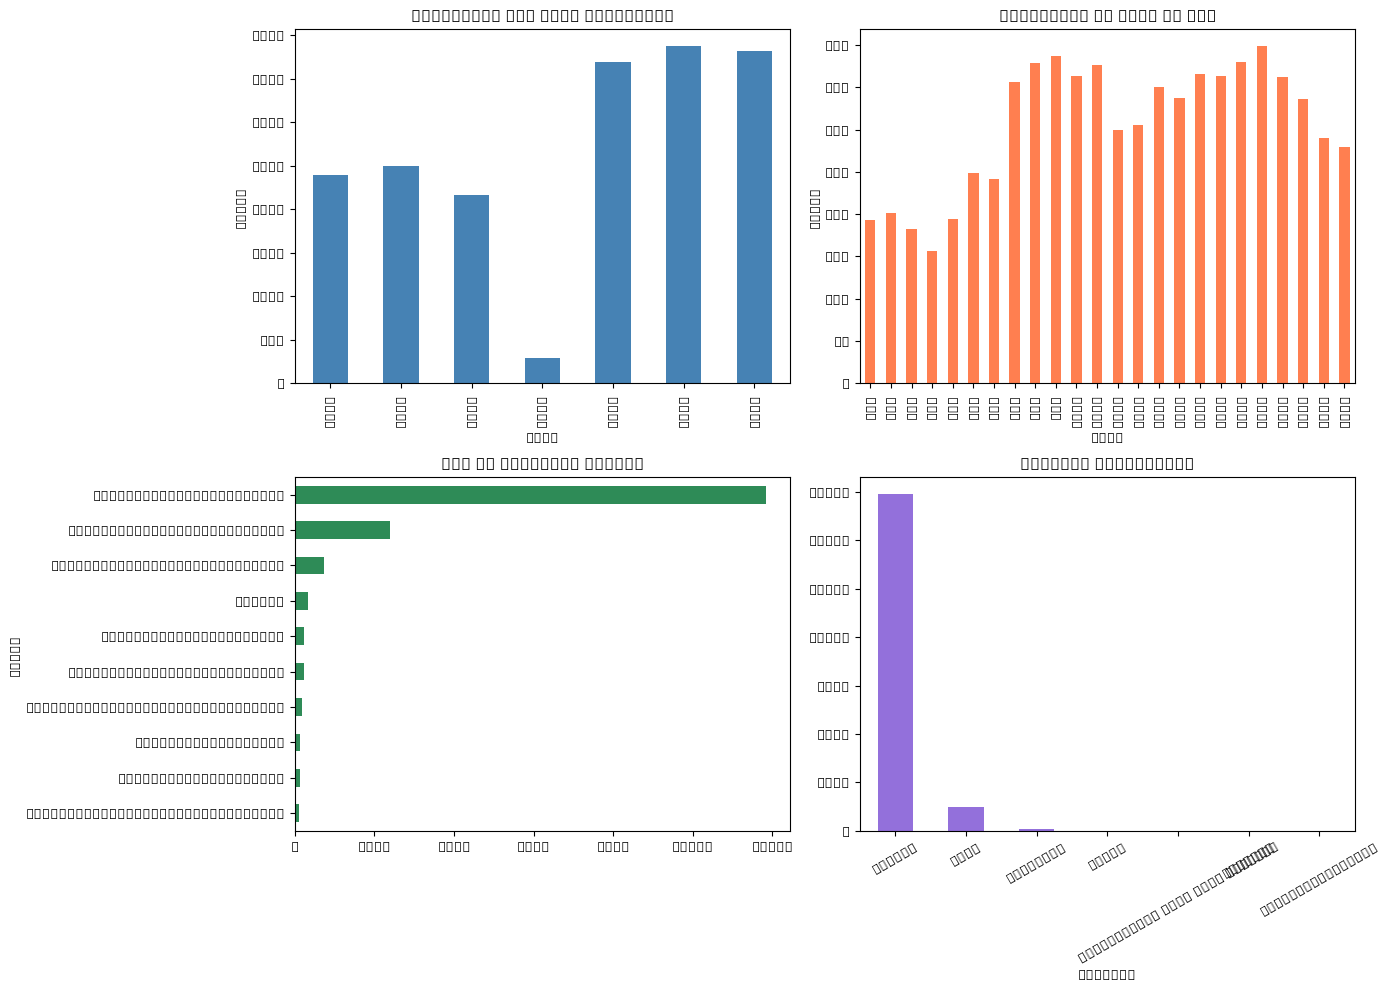

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accidents per year
acc.groupby("year").size().plot(kind="bar", ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Accidents per Year (Bangkok)")
axes[0,0].set_xlabel("Year"); axes[0,0].set_ylabel("Count")

# Accidents per hour
acc["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[0,1], color="coral")
axes[0,1].set_title("Accidents by Hour of Day")
axes[0,1].set_xlabel("Hour"); axes[0,1].set_ylabel("Count")

# Top causes
acc["cause"].value_counts().head(10).plot(kind="barh", ax=axes[1,0], color="seagreen")
axes[1,0].set_title("Top 10 Accident Causes")
axes[1,0].invert_yaxis()

# Weather distribution
acc["weather"].value_counts().head(8).plot(kind="bar", ax=axes[1,1], color="mediumpurple")
axes[1,1].set_title("Weather Conditions")
axes[1,1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_82813/3652726382.py:11: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Gothic.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_82813/3652726382.py:11: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Gothic.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_82813/3652726382.py:11: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Gothic.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_82813/3652726382.py:11: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Gothic.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_82813/3652726382.py:11: UserWarning: Glyph 46 (.) missing from font(s) Noto Sans Gothic.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_82813/3652726382.py:11: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Gothic.
  plt

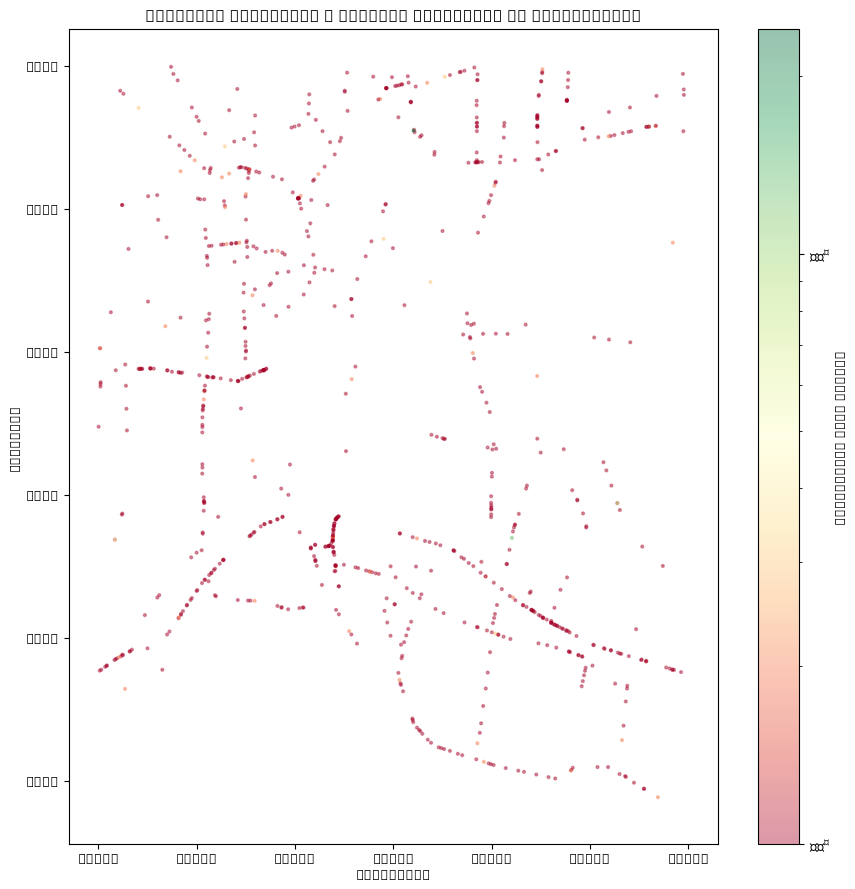

In [4]:
# Spatial scatter — accidents coloured by fatalities
fig, ax = plt.subplots(figsize=(9, 9))
sc = ax.scatter(
    acc["lon"], acc["lat"],
    c=acc["severity"], cmap="RdYlGn",
    s=4, alpha=0.4, norm=mcolors.LogNorm(vmin=1, vmax=acc["severity"].max()+1)
)
plt.colorbar(sc, ax=ax, label="Fatalities (log scale)")
ax.set_title("Accident Locations — Bangkok (coloured by fatalities)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [5]:
# Severity breakdown
print("Fatality stats:")
print(acc["fatalities"].describe())
print(f"\nAccidents with ≥1 fatality: {(acc['fatalities']>=1).sum():,}")
print(f"Accidents with 0 fatalities: {(acc['fatalities']==0).sum():,}")

Fatality stats:
count    18735.000000
mean         0.049533
std          0.307032
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         23.000000
Name: fatalities, dtype: float64

Accidents with ≥1 fatality: 816
Accidents with 0 fatalities: 17,919


## 2. Probe Data (Speed)

In [6]:
# Sample 3 months spread across years to keep memory manageable
sample_files = [
    f"{PROBE_DIR}/PROBE-201901.parquet",
    f"{PROBE_DIR}/PROBE-202201.parquet",
    f"{PROBE_DIR}/PROBE-202501.parquet",
]
probe_frames = []
for f in sample_files:
    try:
        probe_frames.append(pd.read_parquet(f))
    except FileNotFoundError:
        print(f"Missing: {f}")

probe = pd.concat(probe_frames, ignore_index=True)
probe["timestamp"] = pd.to_datetime(probe["timestamp"], errors="coerce")
probe["hour"] = probe["timestamp"].dt.hour

print(f"Probe rows (sample): {len(probe):,}")
probe[["lat","lon","speed","heading","hour"]].describe()

Probe rows (sample): 71,261,673


,lat,lon,speed,heading,hour
count,7.126167e+07,7.126167e+07,7.126167e+07,7.126167e+07,7.126167e+07
mean,1.376827e+01,1.005653e+02,3.644078e+01,1.751712e+02,1.293610e+01
std,9.470538e-02,1.017246e-01,2.366007e+01,1.055733e+02,5.831183e+00
min,1.341461e+01,1.003000e+02,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.370983e+01,1.005021e+02,1.700000e+01,8.900000e+01,9.000000e+00
50%,1.376060e+01,1.005612e+02,3.300000e+01,1.800000e+02,1.300000e+01
75%,1.383035e+01,1.006282e+02,5.200000e+01,2.690000e+02,1.800000e+01
max,1.400000e+01,1.009000e+02,3.940000e+02,6.553300e+04,2.300000e+01


/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/96513145.py:14: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/96513145.py:14: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/96513145.py:14: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/96513145.py:14: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/96513145.py:14: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/96513145.py:14: UserWarning: Glyph 54 (6) missing from font(s) Noto Sans Siddham.
  plt.tight

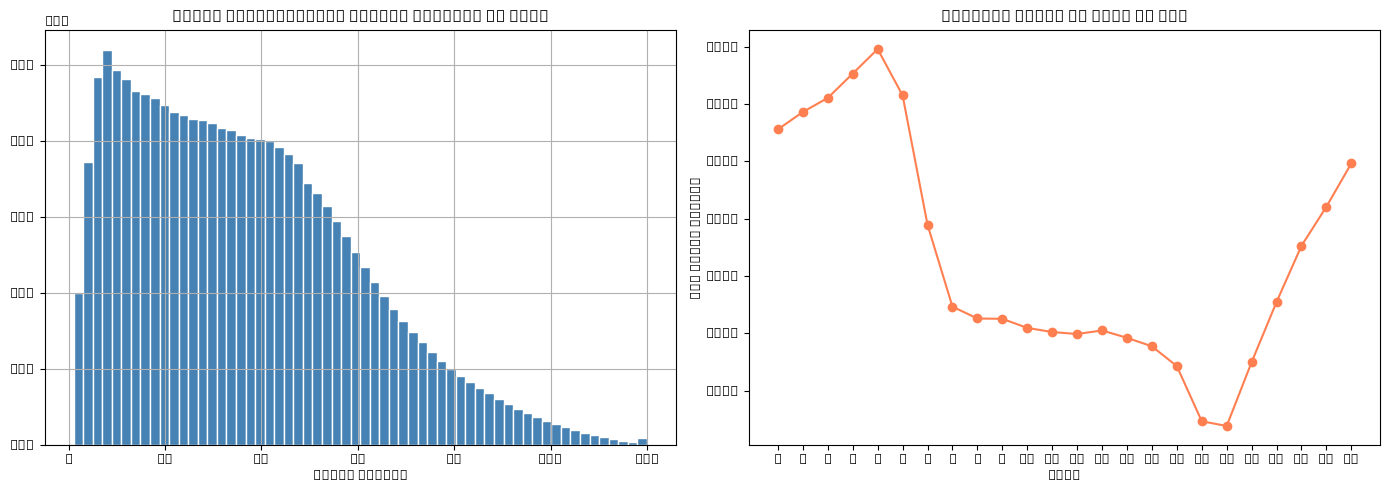

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Speed distribution
probe["speed"].clip(0, 120).hist(bins=60, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Speed Distribution (km/h, clipped at 120)")
axes[0].set_xlabel("Speed (km/h)")

# Average speed by hour
probe.groupby("hour")["speed"].mean().plot(kind="line", marker="o", ax=axes[1], color="coral")
axes[1].set_title("Average Speed by Hour of Day")
axes[1].set_xlabel("Hour"); axes[1].set_ylabel("Avg Speed (km/h)")
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/1575333012.py:11: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/1575333012.py:11: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/1575333012.py:11: UserWarning: Glyph 49 (1) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/1575333012.py:11: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/1575333012.py:11: UserWarning: Glyph 46 (.) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/1575333012.py:11: UserWarning: Glyph 51 (3) missing from font(s) Noto Sans Siddham.

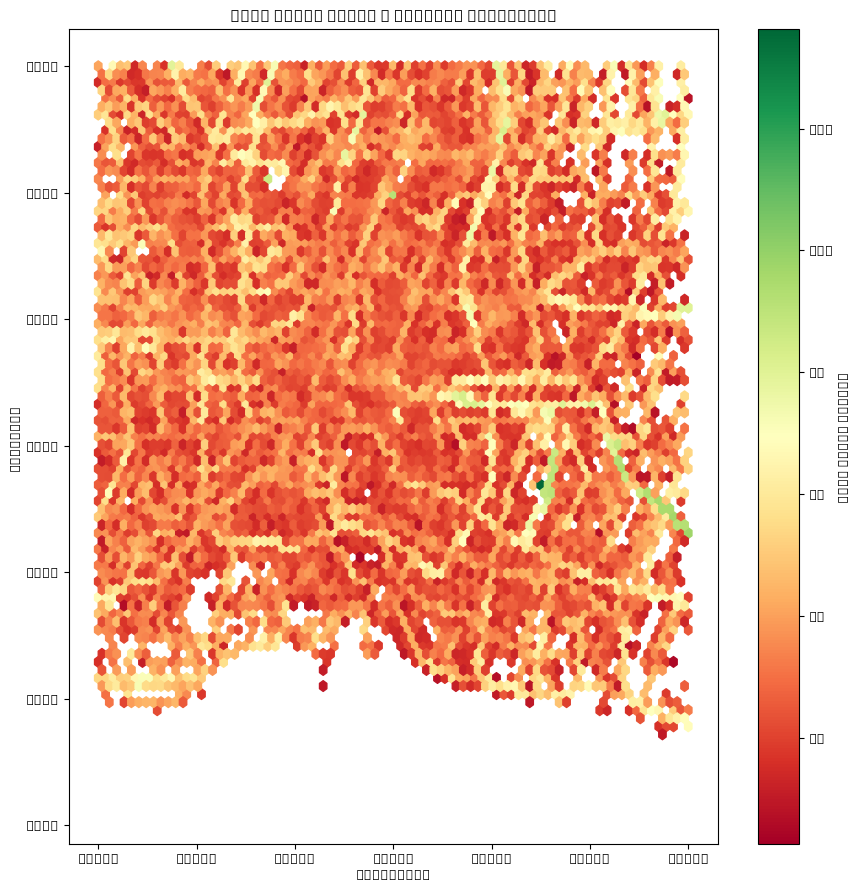

In [8]:
# Spatial density of probe points (hex-bin)
fig, ax = plt.subplots(figsize=(9, 9))
hb = ax.hexbin(
    probe["lon"], probe["lat"],
    C=probe["speed"], reduce_C_function=np.mean,
    gridsize=80, cmap="RdYlGn", mincnt=5
)
plt.colorbar(hb, ax=ax, label="Mean Speed (km/h)")
ax.set_title("Mean Probe Speed — Bangkok (hex-bin)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 3. OSM Layers

In [9]:
roads    = gpd.read_file(f"{OSM_DIR}/osm_roads.gpkg")
poi      = gpd.read_file(f"{OSM_DIR}/osm_poi.gpkg")
landuse  = gpd.read_file(f"{OSM_DIR}/osm_landuse.gpkg")
buildings = gpd.read_file(f"{OSM_DIR}/osm_buildings.gpkg")

print(f"Roads:     {len(roads):,} features | CRS: {roads.crs}")
print(f"POI:       {len(poi):,} features")
print(f"Landuse:   {len(landuse):,} features")
print(f"Buildings: {len(buildings):,} features")

Roads:     251,567 features | CRS: EPSG:4326
POI:       9,489 features
Landuse:   13,720 features
Buildings: 188,077 features


/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/1305462036.py:19: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/1305462036.py:19: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/1305462036.py:19: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/1305462036.py:19: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/1305462036.py:19: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/1305462036.py:19: UserWarning: Glyph 54 (6) missing from font(s) Noto Sans Siddham.

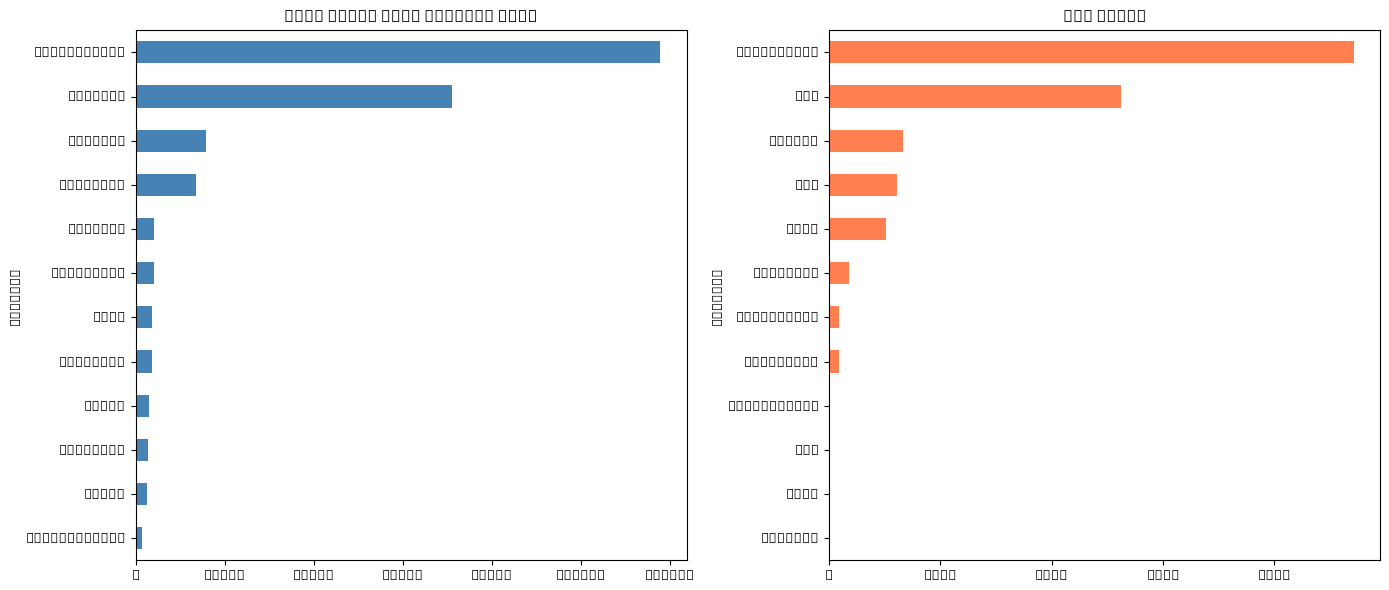

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Road type distribution
if "highway" in roads.columns:
    roads["highway"].value_counts().head(12).plot(
        kind="barh", ax=axes[0], color="steelblue"
    )
    axes[0].set_title("Road Types (OSM highway tag)")
    axes[0].invert_yaxis()

# POI type distribution
poi_type = poi["amenity"].fillna(poi["shop"] if "shop" in poi.columns else "")
poi_type.value_counts().head(12).plot(
    kind="barh", ax=axes[1], color="coral"
)
axes[1].set_title("POI Types")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Cross-Dataset Overlay
Do accidents cluster in low-speed (congested) or high-speed zones?

In [11]:
# Grid-based overlay: 0.01° cells (~1 km)
CELL = 0.01

acc["grid_lon"] = (acc["lon"] / CELL).round() * CELL
acc["grid_lat"] = (acc["lat"] / CELL).round() * CELL
acc_grid = acc.groupby(["grid_lon","grid_lat"]).agg(
    acc_count=("year","count"),
    fatalities=("fatalities","sum")
).reset_index()

probe["grid_lon"] = (probe["lon"] / CELL).round() * CELL
probe["grid_lat"] = (probe["lat"] / CELL).round() * CELL
probe_grid = probe.groupby(["grid_lon","grid_lat"]).agg(
    mean_speed=("speed","mean"),
    probe_count=("speed","count")
).reset_index()

merged = acc_grid.merge(probe_grid, on=["grid_lon","grid_lat"], how="inner")
print(f"Overlapping grid cells: {len(merged):,}")
merged.head()

Overlapping grid cells: 897


,grid_lon,grid_lat,acc_count,fatalities,mean_speed,probe_count
0,100.3,13.57,2,0,47.583808,3866
1,100.3,13.58,20,2,63.838976,6291
2,100.3,13.65,4,0,47.709245,12072
3,100.3,13.74,7,0,50.085462,3054
4,100.3,13.75,11,1,53.756641,11481


/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/150104017.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby("speed_bin")["acc_count"].mean().plot(
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/150104017.py:22: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/150104017.py:22: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/150104017.py:22: UserWarning: Glyph 50 (2) missing from font(s) Noto Sans Siddham.
  plt.tight_layout()
/var/folders/8c/ttrqjvgn62x_53dxr6sk5pg40000gn/T/ipykernel_72241/150104017.py:22: UserWarning: Glyph 48 (0) missing f

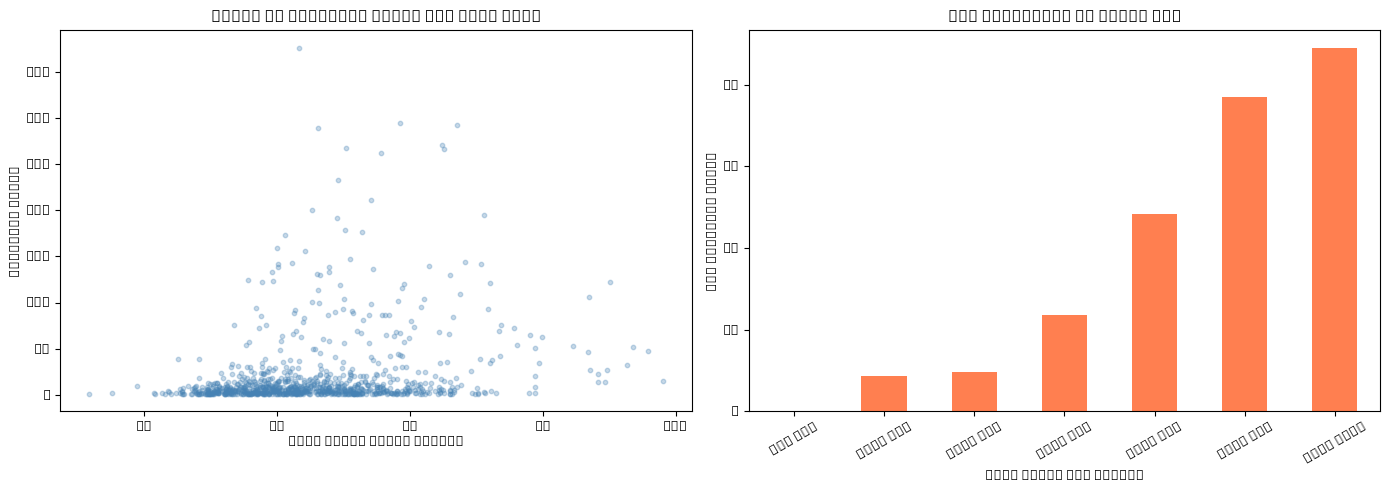

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: mean speed vs accident count
axes[0].scatter(
    merged["mean_speed"], merged["acc_count"],
    alpha=0.3, s=10, color="steelblue"
)
axes[0].set_xlabel("Mean Probe Speed (km/h)")
axes[0].set_ylabel("Accident Count")
axes[0].set_title("Speed vs Accident Count per Grid Cell")

# Speed bins vs avg accidents
merged["speed_bin"] = pd.cut(merged["mean_speed"], bins=[0,10,20,30,40,60,80,120])
merged.groupby("speed_bin")["acc_count"].mean().plot(
    kind="bar", ax=axes[1], color="coral"
)
axes[1].set_title("Avg Accidents by Speed Bin")
axes[1].set_xlabel("Mean Speed Bin (km/h)")
axes[1].set_ylabel("Avg Accident Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [13]:
# Correlation
corr = merged[["mean_speed","acc_count","fatalities","probe_count"]].corr()
print("Correlation matrix:")
corr

Correlation matrix:


,mean_speed,acc_count,fatalities,probe_count
mean_speed,1.000000,0.234618,0.064180,-0.332753
acc_count,0.234618,1.000000,0.239790,0.113697
fatalities,0.064180,0.239790,1.000000,0.031927
probe_count,-0.332753,0.113697,0.031927,1.000000


## 6. Accidents Overlaid on Road Network (Thai CRS)

In [14]:
# --- Load & reproject to Thai UTM (EPSG:32647) ---
roads = gpd.read_file(f"{OSM_DIR}/osm_roads.gpkg")
roads_utm = roads[roads.geom_type == 'LineString'].to_crs(THAI_CRS)

# Build accident GeoDataFrame (drop rows with missing coords)
bkk_frames = []
for f in sorted(glob.glob(f"{BKK_ACC_DIR}/accidents_bangkok_*.csv")):
    bkk_frames.append(pd.read_csv(f, encoding='utf-8-sig').rename(columns=COL_MAP))
if not bkk_frames:
    for f in sorted(glob.glob(f"{ACC_DIR}/accidents_*.csv")):
        df = pd.read_csv(f, encoding='utf-8-sig').rename(columns=COL_MAP)
        bkk_frames.append(df[df['lat'].between(BBOX['lat_min'], BBOX['lat_max']) & df['lon'].between(BBOX['lon_min'], BBOX['lon_max'])].copy())
acc = pd.concat(bkk_frames, ignore_index=True)
acc['severity'] = acc['fatalities'].fillna(0).astype(int)

acc_gdf = gpd.GeoDataFrame(
    acc,
    geometry=gpd.points_from_xy(acc['lon'], acc['lat']),
    crs='EPSG:4326'
).to_crs(THAI_CRS)

print(f"Roads (LineString): {len(roads_utm):,}")
print(f"Accidents: {len(acc_gdf):,}")
print(f"CRS: {acc_gdf.crs}")

Roads (LineString): 232,333
Accidents: 18,735
CRS: EPSG:32647


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Siddham.
  ax.figure.canvas.draw_idle()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Siddham.
  ax.figure.canvas.draw_idle()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 54 (6) missing from font(s) Noto Sans Siddham.
  ax.figure.canvas.draw_idle()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Siddham.
  ax.figure.canvas.draw_idle()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Siddham.
  ax.figu

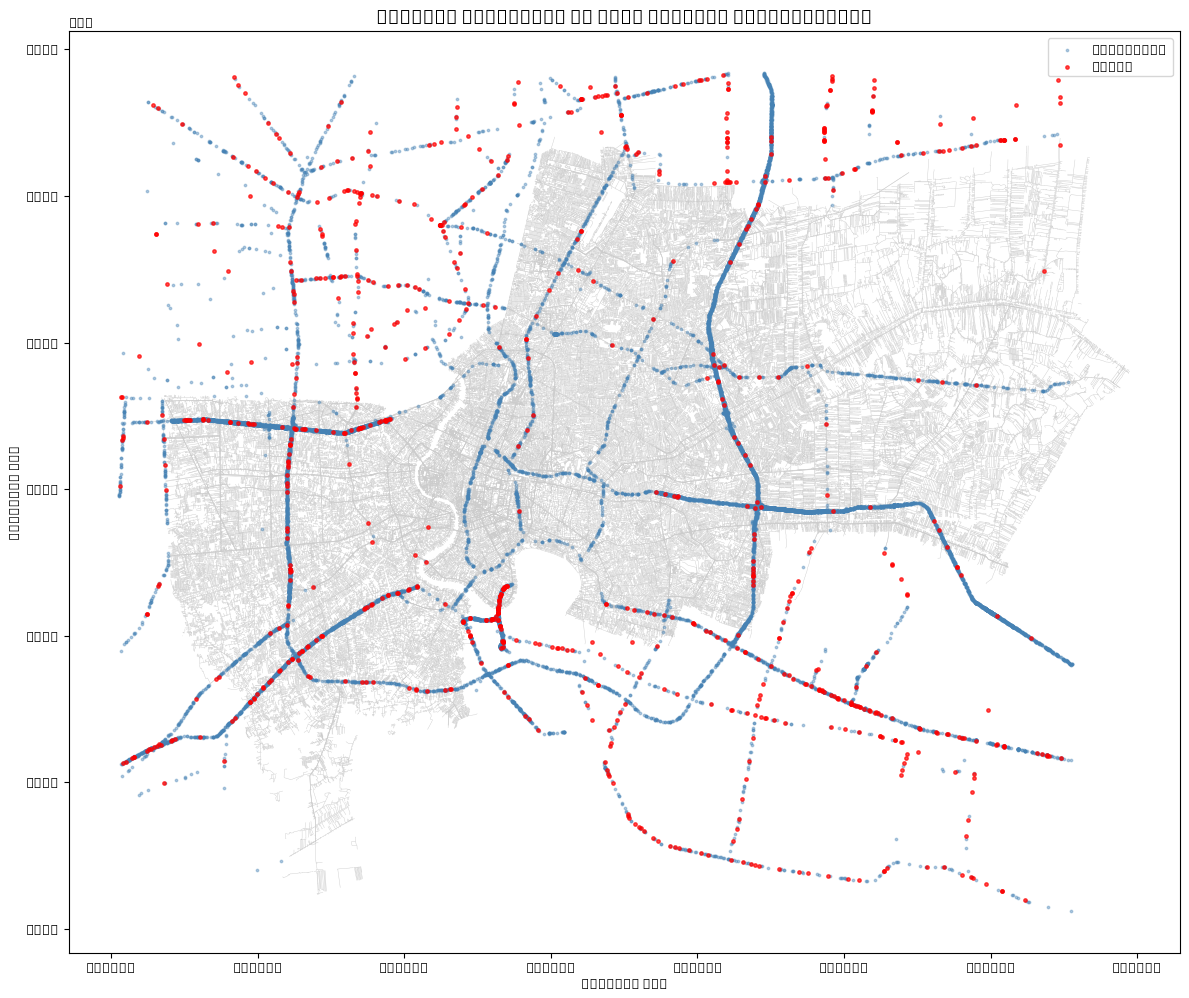

In [15]:
# --- Full Bangkok map: roads + accidents coloured by fatalities ---
fig, ax = plt.subplots(figsize=(12, 12))

# Road network (grey, thin)
roads_utm.plot(ax=ax, color='#cccccc', linewidth=0.3, zorder=1)

# Accidents: split fatal vs non-fatal for clarity
non_fatal = acc_gdf[acc_gdf['severity'] == 0]
fatal     = acc_gdf[acc_gdf['severity'] >= 1]

non_fatal.plot(ax=ax, color='steelblue', markersize=3, alpha=0.4, zorder=2, label='Non-fatal')
fatal.plot(ax=ax, color='red', markersize=6, alpha=0.7, zorder=3, label='Fatal')

ax.set_title('Bangkok Accidents on Road Network (EPSG:32647)', fontsize=14)
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Siddham.
  ax.figure.canvas.draw_idle()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Siddham.
  ax.figure.canvas.draw_idle()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 54 (6) missing from font(s) Noto Sans Siddham.
  ax.figure.canvas.draw_idle()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 53 (5) missing from font(s) Noto Sans Siddham.
  ax.figure.canvas.draw_idle()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Siddham.
  ax.figu

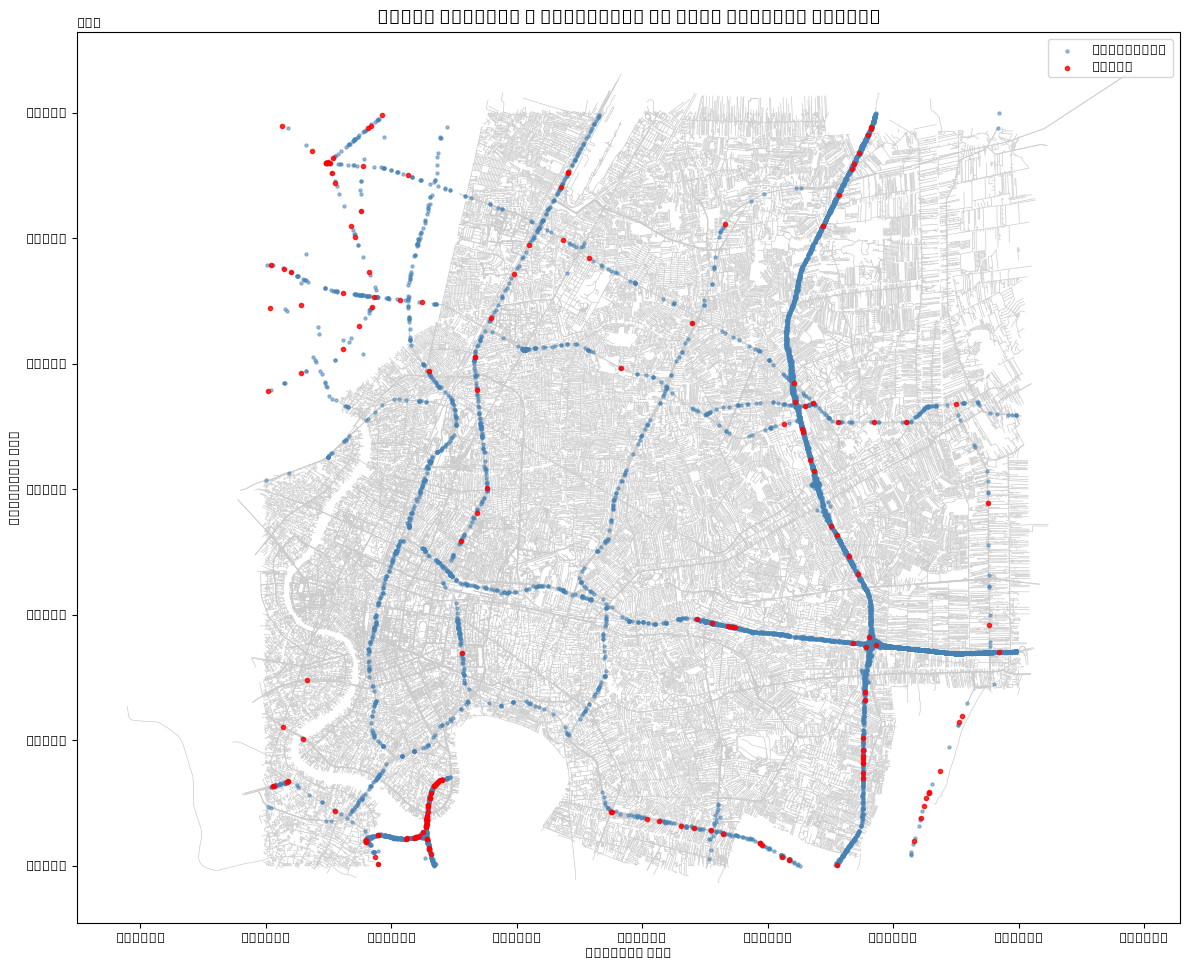

In [16]:
# --- Zoom into inner Bangkok (approx. city core) ---
# UTM 47N approx bounds for inner Bangkok
X_MIN, X_MAX = 660_000, 690_000
Y_MIN, Y_MAX = 1_510_000, 1_540_000

roads_zoom = roads_utm.cx[X_MIN:X_MAX, Y_MIN:Y_MAX]
acc_zoom   = acc_gdf.cx[X_MIN:X_MAX, Y_MIN:Y_MAX]

fig, ax = plt.subplots(figsize=(12, 12))
roads_zoom.plot(ax=ax, color='#cccccc', linewidth=0.5, zorder=1)

non_fatal_z = acc_zoom[acc_zoom['severity'] == 0]
fatal_z     = acc_zoom[acc_zoom['severity'] >= 1]

non_fatal_z.plot(ax=ax, color='steelblue', markersize=5, alpha=0.5, zorder=2, label='Non-fatal')
fatal_z.plot(ax=ax, color='red', markersize=9, alpha=0.8, zorder=3, label='Fatal')

ax.set_title('Inner Bangkok — Accidents on Road Network (zoom)', fontsize=14)
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Siddham.
  ax.figure.canvas.draw_idle()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Siddham.
  ax.figure.canvas.draw_idle()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 54 (6) missing from font(s) Noto Sans Siddham.
  ax.figure.canvas.draw_idle()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 52 (4) missing from font(s) Noto Sans Siddham.
  ax.figure.canvas.draw_idle()
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 48 (0) missing from font(s) Noto Sans Siddham.
  ax.figu

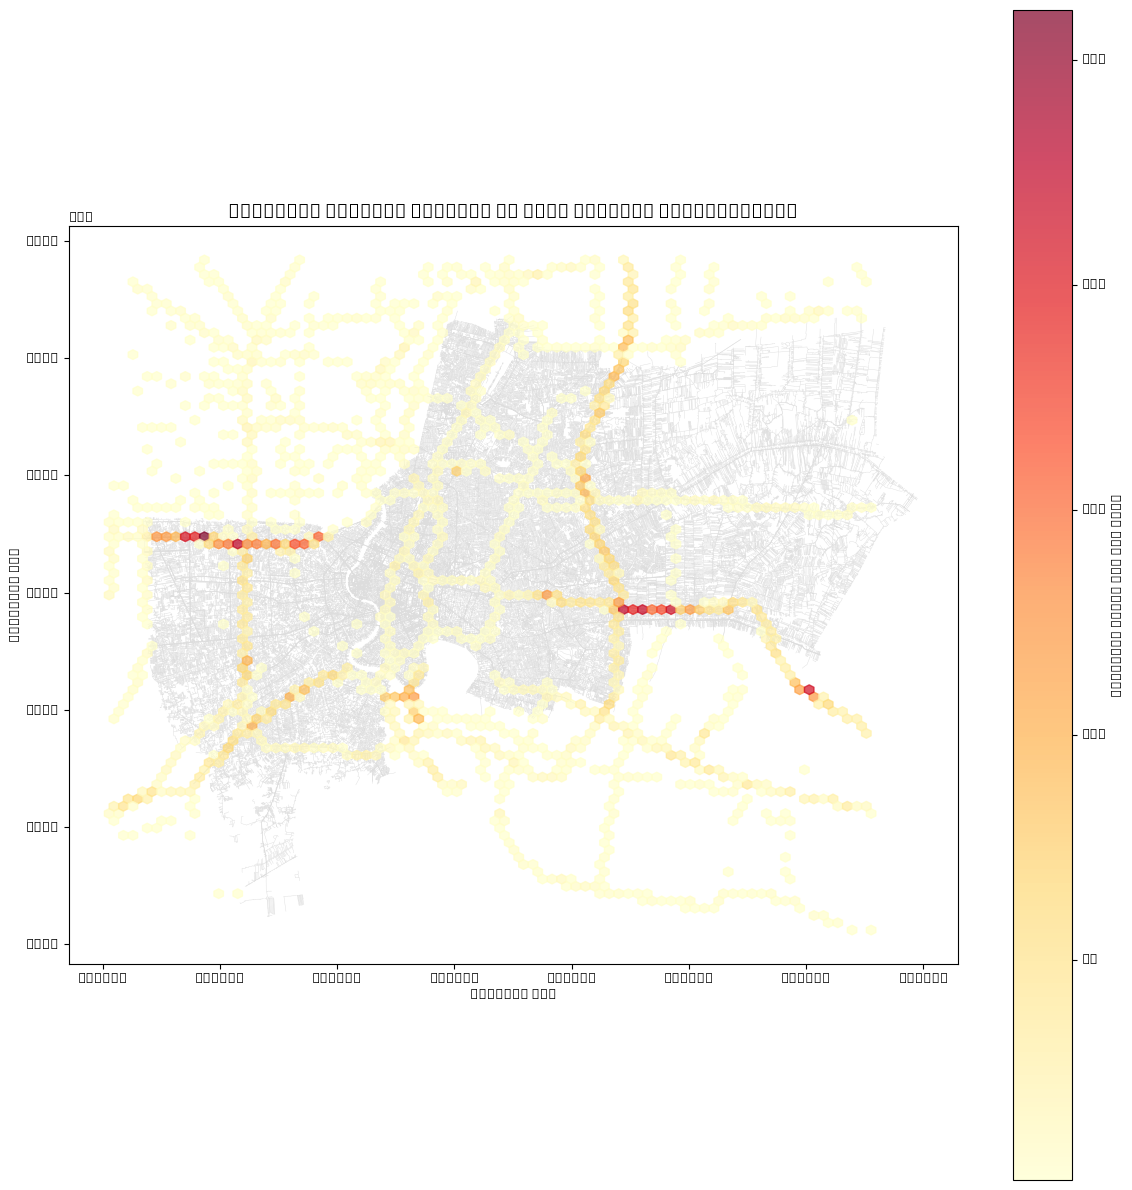

In [17]:
# --- Heatmap: accident density on road network ---
# Convert accident coords to numpy for hexbin
xs = acc_gdf.geometry.x.values
ys = acc_gdf.geometry.y.values

fig, ax = plt.subplots(figsize=(12, 12))
roads_utm.plot(ax=ax, color='#dddddd', linewidth=0.3, zorder=1)
hb = ax.hexbin(xs, ys, gridsize=80, cmap='YlOrRd', mincnt=1, alpha=0.7, zorder=2)
plt.colorbar(hb, ax=ax, label='Accident count per hex cell')
ax.set_title('Accident Density Heatmap on Road Network (EPSG:32647)', fontsize=14)
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
plt.tight_layout()
plt.show()